## Introduction 

In [1]:
# read() read all the file as string, and splitlines() splits by new line '/n'
names = open('names.txt', 'r').read().splitlines() 

In [2]:
names[:5], len(names)

(['emma', 'olivia', 'ava', 'isabella', 'sophia'], 32033)

In [3]:
min(names, key=len) # shortest name

'an'

In [4]:
max(names, key=len) # largest name

'muhammadibrahim'

### Character Level Language Model

<p style="font-size:18px;">
    <b>Intuition:</b> is to predict the next character in a sequence of characters.
    Take for example the name <code>Omar</code>. What can we extract from this name?
</p>

<ul style="font-size:18px;">
    <li>
        <b>O</b> — a character that most likely begins a name.
    </li>
    <li>
        <b>m</b> — a character that most likely follows <b>o</b> in a name.
    </li>
    <li>
        <b>a</b> — a character that most likely follows <b>m</b> in a given name.
    </li>
    <li>
        <b>r</b> — a character that most likely follows <b>a</b>, and also indicates the name ends
        (<span style="color: rgb(255, 148, 148);">
            i.e., there are no more characters and generation should stop
        </span>).
    </li>
</ul>

<p style="font-size:18px;">
    So it is a statistical model, based on frequency of characters. 
</p>


In [5]:
for w in names[:1]: # sliding window of size two charactes
    for w1, w2 in zip(w, w[1:]): 
        print(w1, w2)

e m
m m
m a


In [6]:
for w in names[:1]:
    chs = ['<S>'] + list(w) + ['<W>'] # ['<S>', 'e', 'm', 'm', 'a', '<E>']
    for w1, w2 in zip(chs, chs[1:]): 
        print(w1, w2)

<S> e
e m
m m
m a
a <W>


In [7]:
for w in names[:3]:
    chs = ['<S>'] + list(w) + ['<W>'] # ['<S>', 'e', 'm', 'm', 'a', '<E>']
    for w1, w2 in zip(chs, chs[1:]): 
        print(w1, w2)

<S> e
e m
m m
m a
a <W>
<S> o
o l
l i
i v
v i
i a
a <W>
<S> a
a v
v a
a <W>


<p style="font-size:18px;">
we then create a dictionary that counts each one of these Bigram, like what is the most likely character to follow <br>    <code> '< S >' </code>, that will be the most character that start a word, what is the most character that likely to follow, 
        a an arbitrary character m, etc. 
</p>




In [8]:
b = {}
for w in names[:3]:
    chs = ['<S>'] + list(w) + ['<W>'] 
    for w1, w2 in zip(chs, chs[1:]): 
        bigram = (w1, w2) # create a tuple
        
        b[bigram] = b.get(bigram, 0) + 1 
        # b.get() will check if bigram exist if not, return 0, instead of an error. And then add 1. 
    

In [9]:
b # ('a', '<W>'): 3 were the most likely pair of these 3 words, the 3 words ended with 'a'. 

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<W>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [10]:
b = {}
for w in names:
    chs = ['<S>'] + list(w) + ['<W>'] 
    for w1, w2 in zip(chs, chs[1:]): 
        bigram = (w1, w2) 
        b[bigram] = b.get(bigram, 0) + 1 

In [11]:
max(b, key=b.get)

('n', '<W>')

In [12]:
b.get(('n', '<W>')) 

6763

<p style ="font-size:18ps;"> 6763 words ended with a character <b> n </b> </p>

In [13]:
min(b, key=b.get)

('q', 'r')

In [14]:
b.get(('n', 'r'))

44

<p style ="font-size:18ps;"> least frequent pair is<b> n </b> followed by <b> r </p>

In [15]:
sorted(b.items(), key=lambda x: x[1], reverse=True)[:10]

[(('n', '<W>'), 6763),
 (('a', '<W>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<W>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963)]

## Create Bigram in a Tensor for efficiency

In [16]:
import torch

In [17]:
N = torch.zeros(28, 28, dtype=torch.int32) # all english alphabet plus <S> and <E>
# co-occurrence matrix of all alphabets with each other

In [18]:
alpha = sorted(list(set(''.join(names)))) 
# join all words into a single list, remove duplicated, sort it, we get all the alphabet ordered

In [19]:
# Then map each character into a number like a dict
# String into a index stoi
stoi = {s:i for i, s in enumerate(alpha)}
stoi['a']

0

In [20]:
# Then add two special characters 
stoi['<S>'] = 26
stoi['<E>'] = 27


In [21]:
# Use our look up table of each character, to index the tensor and count each letter
for w in names: 
    chs = ['<S>'] + list(w) + ['<E>']
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        N[index1, index2] += 1

In [22]:
import matplotlib.pyplot as plt
%matplotlib inline

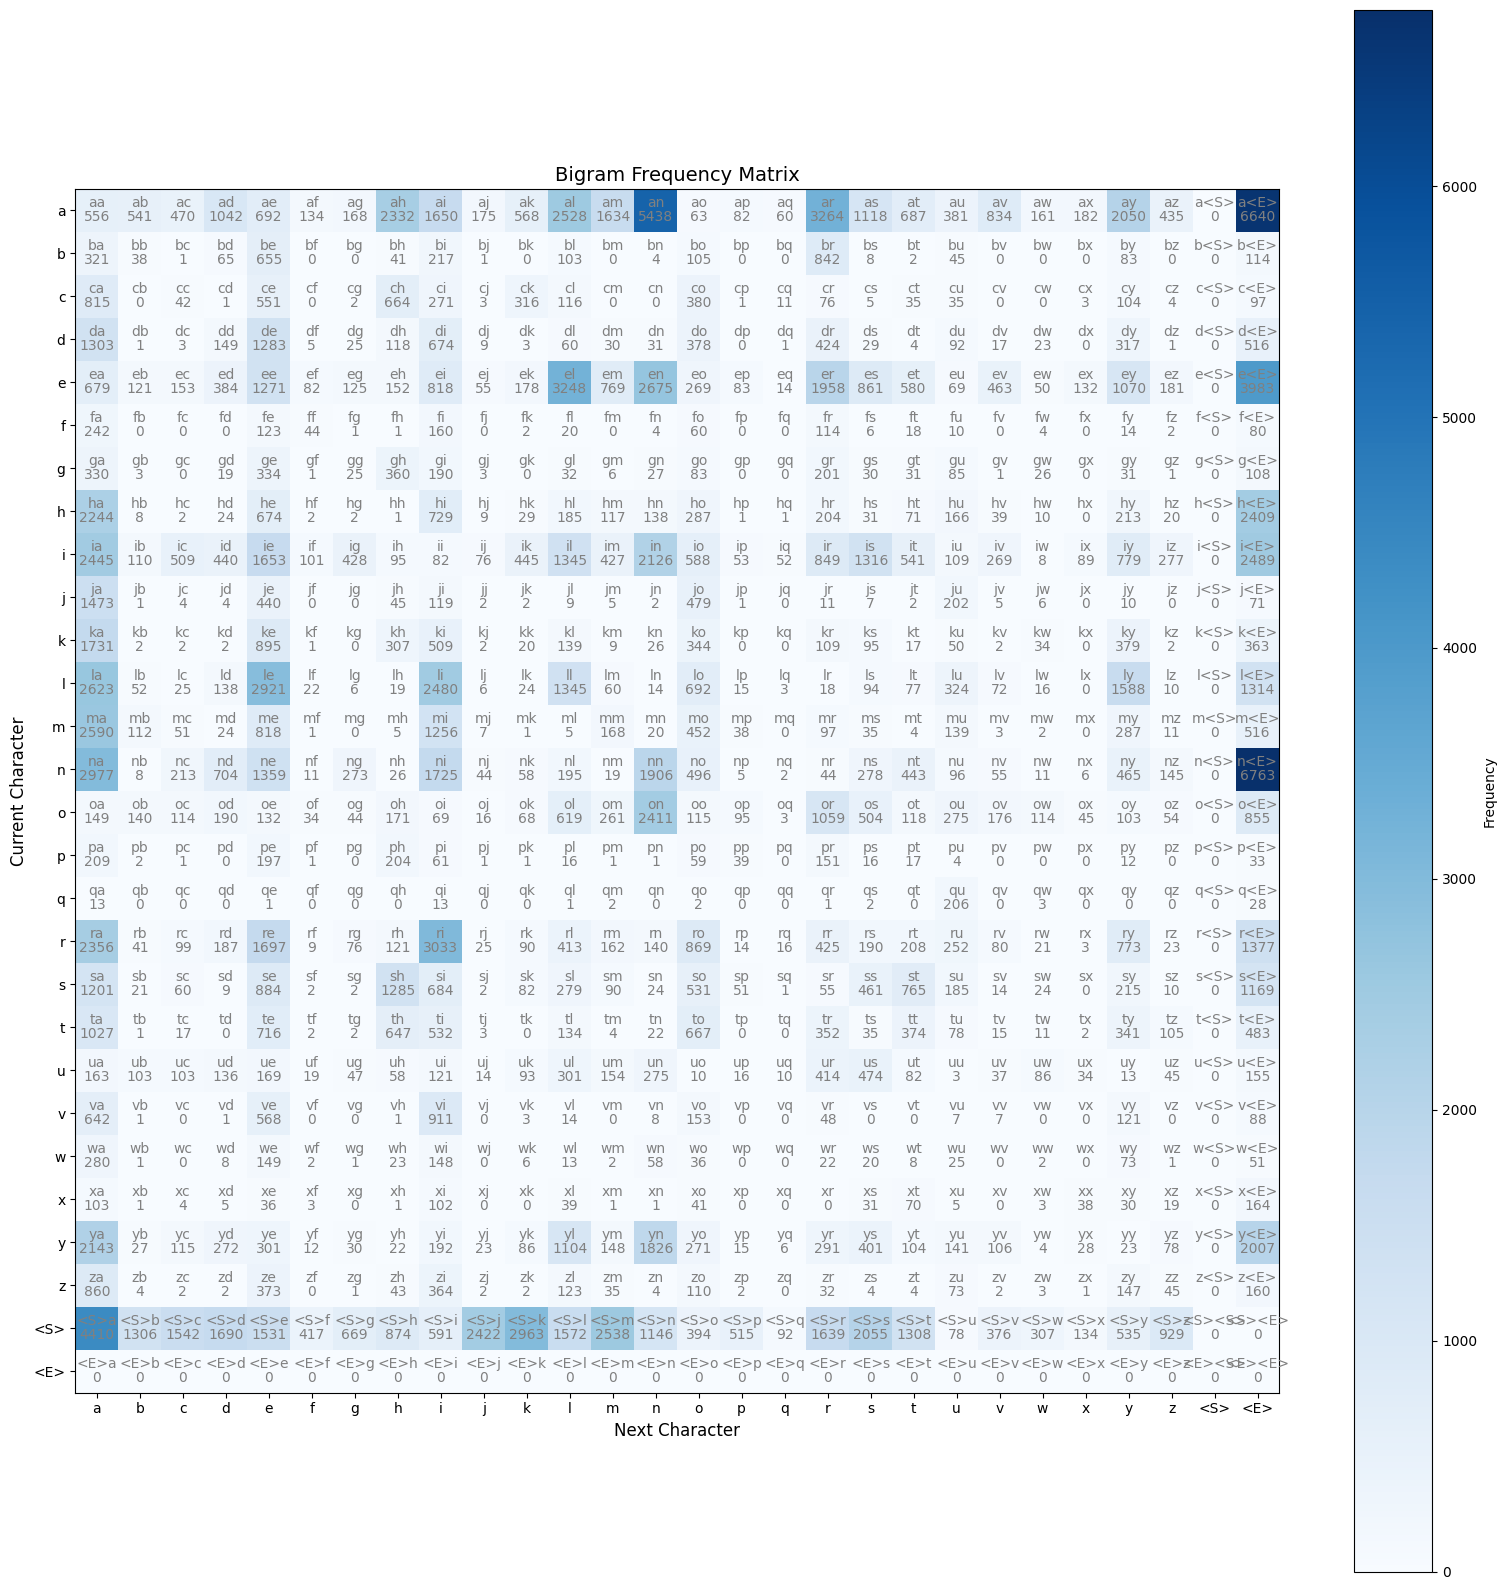

In [ ]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')

itos = {i: s for s, i in stoi.items()} # reverse index to string

for i in range(28):
    for j in range(28):
        bigram = itos[i] + itos[j] # two characters aa, ab, ac, etc
        
        count = N[i, j].item()  # .item() to extract number from tensor
        
        plt.text(j, i, bigram, ha="center", va="bottom", color='gray')
        plt.text(j, i, count, ha="center", va="top", color='gray')
        

plt.xticks(range(28), [itos[i] for i in range(28)], fontsize=10)
plt.yticks(range(28), [itos[i] for i in range(28)], fontsize=10)
plt.xlabel('Next Character', fontsize=12)
plt.ylabel('Current Character', fontsize=12)
plt.title('Bigram Frequency Matrix', fontsize=14)
plt.colorbar(label='Frequency')
plt.tight_layout()
plt.show()

### Interpreting the Matrix 

<p style="font-size:18px;"> As you can see the Last Row, <code>< E ></code> is starting zero times, because it is a special token that defines a end of a name. So it is starting zero times.<br> <br>
    Also the column before the ending <code> < S > </code> is also ending zero times. Because that is a special token to denote a the starting letter of a name. <br> </p>

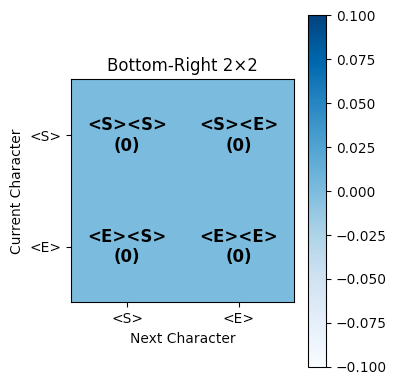

<p style="font-size:18px;"> As you can see the these special tokens never follow each other, so we have a wasted space, so we this by removing one special character, and leaving only one. </p>

### Removing one special token

In [ ]:
N = torch.zeros((27, 27), dtype=torch.int)

In [25]:
stoi = {s:i+1 for i, s in enumerate(alpha)} # start from one
stoi['.'] = 0 # Special token at zeroth position. 
stoi['.']

0

In [26]:
for w in names: 
    chs = ['.'] + list(w) + ['.'] # '.'. at the start '.' at the end of name
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        N[index1, index2] += 1

In [27]:
itos = {i: s for s, i in stoi.items()} 
itos[0], itos[1]

('.', 'a')

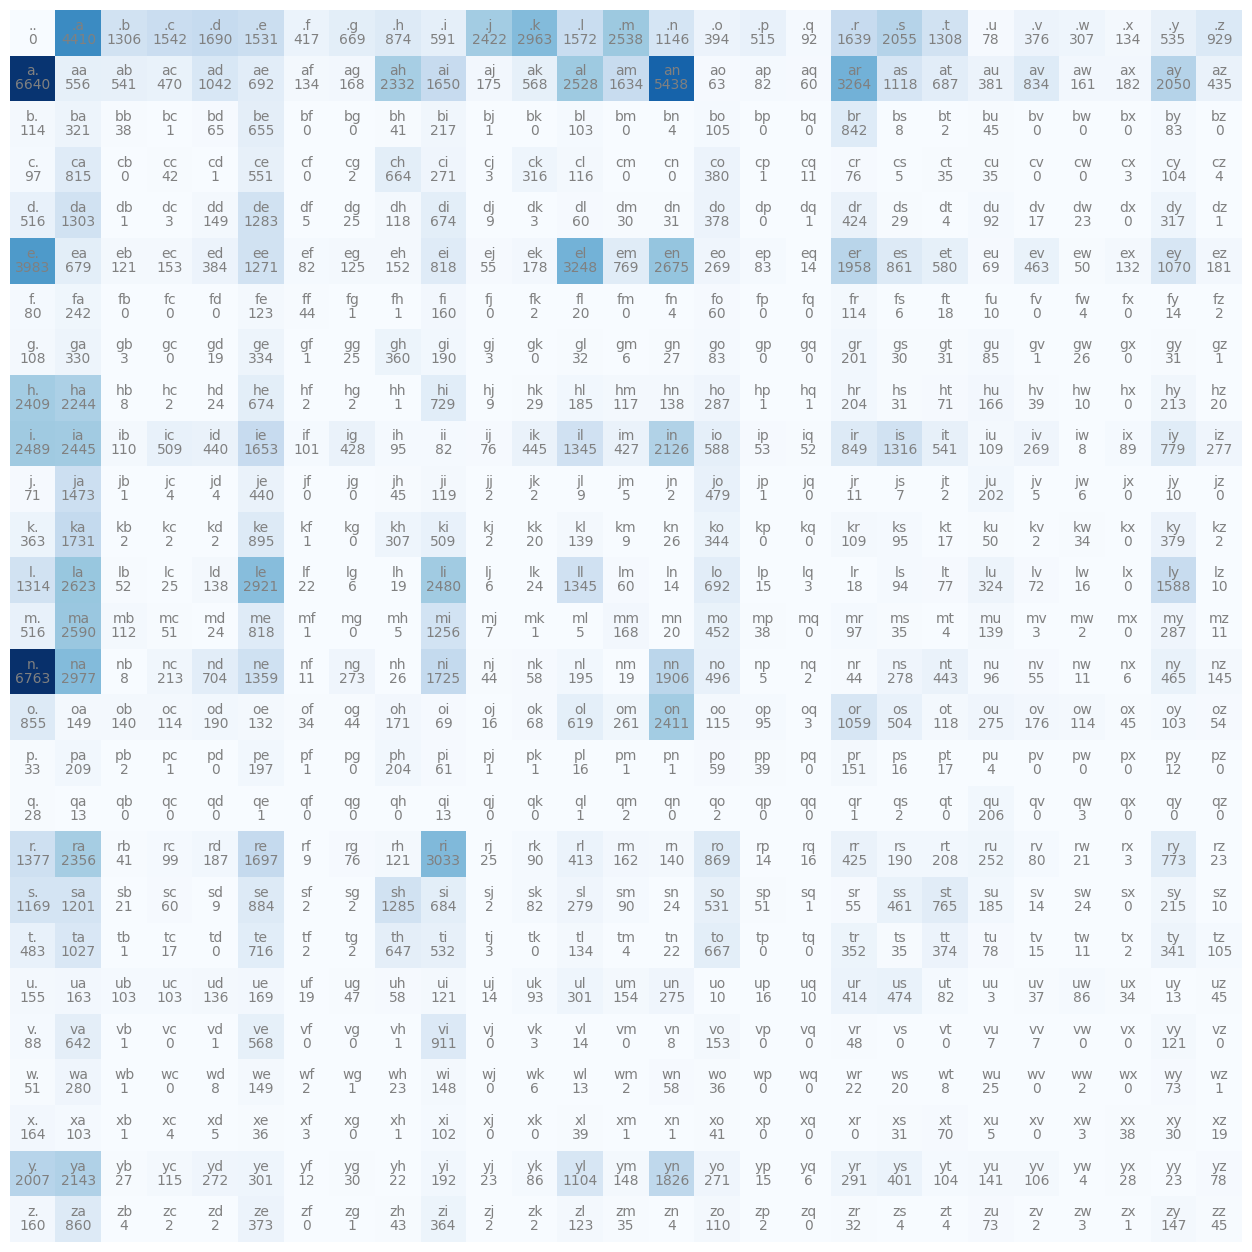

In [ ]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        bigram = itos[i] + itos[j] # two characters aa, ab, ac, etc
        
        count = N[i, j].item()  # .item() to extract number from tensor
        
        plt.text(j, i, bigram, ha="center", va="bottom", color='gray')
        plt.text(j, i, count, ha="center", va="top", color='gray')
        
plt.axis('off');

<p style="font-size:18px;"> Now!! '..' appears zero time, because they never follow each other and we have less wasted rows and columns</p>

## Multinomial Distribution

<p style="font-size:18px;"> We are going to use Multinomial Dist. I will explain it briefly here, but you could watch this video <a href=https://www.youtube.com/watch?v=Dkc_hcVWDpA>here</a> To get a better grasp.<br> <br> 
The whole idea, given a for a number of categories, and I want to sample from it, what numbers will be drawn back. Like I have a bag that contain 20 red balls, 50 green balls, 30 blue balls. And I have taken for example 10 random balls with replacement i.e I draw the ball and put it back again, what is the probability to get 3 red balls out of the ten or 1 red, 4 green, 5 blue, etc. Of course the underlying probability of the all possibilities should sum to one. 20% + 50% + 30% = 1, to get the probability of each one, we divide the number of each category balls over the sum. $$red ball = \dfrac{20}{20+50+30} = 20\%$$   </p

In [29]:
'''
we use manual seed, so we get the same results, i.e to get a reproducable resutls
so that torch.rand() will genreate the  same random numbers for this number of manual seed
'''
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p 

tensor([0.7081, 0.3542, 0.1054])

<b>We have three random numbers, let's sum and divide each one by the total to get a probability distribution<b>

In [30]:
p = p/p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

<b>The probability of getting the first is one is 60% and second is 30% and third is almost 10%, in other words
    the probability of getting the first number is 6 times more likely than the third, and two times more likely than the second<b>

In [31]:
samples= torch.multinomial(p, num_samples=15, replacement=True, generator=g)
samples

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0])

<b><span style="font-weight:700; color: rgb(255, 148, 148);">
   As you can see we get 0 more times than (1 and 2 individually) and 2 is more times than zero, as the number of samples increase it should approach 60%, 30%,10% based on the Law of Large Numbers. 
</span>
<b>

In [32]:
# count occurrences
counts = torch.bincount(samples)

# normalize by total
proportions = counts / samples.numel()

counts, proportions

(tensor([7, 6, 2]), tensor([0.4667, 0.4000, 0.1333]))

<b> As you can 0 is about 50%, and 1 is 40% and 2 is 6% </b>

In [33]:
samples= torch.multinomial(p, num_samples=500, replacement=True, generator=g)
counts = torch.bincount(samples)
proportions = counts / samples.numel()

counts, proportions

(tensor([305, 157,  38]), tensor([0.6100, 0.3140, 0.0760]))

<b> Get more closer to the real expected numbers of distribution </b>

### Now applying Multinomial  Distribution to the N matrix of bigrams

In [34]:
N.shape

torch.Size([27, 27])

<p style="font-size:18px;"> We have 27,27 Matrix, so we have for each letter and special token, how many occurrences happened followed by each letter, based on our text data we have. Rows contain letters and special token and columns for each contain the number of occurrences with that row. 
</p>

In [35]:
itos[0],N[0]

('.',
 tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929], dtype=torch.int32))

That means '.' occurred zero times after '.'
- 'a' occurred 4410 times after '.'
- 'b' occurred 1306 after '.'
etc

In [36]:
p = N[0].float() # we make it float since we are going to divide
p = p /p.sum() # and we each entry over sum to get a probability
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

These probabilities should sum to one

In [37]:
p.sum()

tensor(1.)

In [38]:
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g)
ix.item() # item() extract number from tensor

13

In [39]:
itos[ix.item()]

'm'

And it makes sense, if you look at the occurrences of 'm' after '.' it happened 2538, so it makes sense to appear in a sample, since it has a high probability to be chosen. 

Now we make a loop of drawn samples to get a name, like after 'm', we see which character is more likely to be 
be chosen after m, etc, until we hit a .

In [40]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20): 
    out = []
    ix = 0 
    while True: 
        p = N[ix].float()
        p = p / p.sum()
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0: # we sampled '.' the name has ended
            break

    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


<p style="font-size:18px;"> By the way this names, while they appear to be bad, they are actually better, if you compare them, to untrained mode, like that have uniform of distribution i.e not trained on any dataset, every character chance has the same probability as the other</p>

In [41]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20): 
    out = []
    ix = 0 
    while True: 
        p = torch.ones(27) / 27.0
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0: # we sampled '.' the name has ended
            break

    print(''.join(out))

cexzm.
zoglkurkicqzktyhwmvmzimjttainrlkfukzkktda.
sfcxvpubjtbhrmgotzx.
iczixqctvujkwptedogkkjemkmmsidguenkbvgynywftbspmhwcivgbvtahlvsu.
dsdxxblnwglhpyiw.
igwnjwrpfdwipkwzkm.
desu.
firmt.
gbiksjbquabsvoth.
kuysxqevhcmrbxmcwyhrrjenvxmvpfkmwmghfvjzxobomysox.
gbptjapxweegpfwhccfyzfvksiiqmvwbhmiwqmdgzqsamjhgamcxwmmk.
iswcxfmbalcslhy.
fpycvasvz.
bqzazeunschck.
wnkojuoxyvtvfiwksddugnkul.
fuwfcgjz.
abl.
j.
nuuutstofgqzubbo.
rdubpknhmd.


<b><span style="font-weight:700; color: rgb(230, 0, 0);">
    Comparing to the bigram model NOW!!, it seems a lot worse. <br><br></span>
    
<span style="font-weight:700; color: rgb(0, 200, 100);" > The bigram model, only focus on the previous characters, that is why sometimes, it would output like 'x.' just one name, it has no vision of the previous character it only sees the last character and predict the next one based on probability, while it is bad overall, it is better than a random chosen characters</span>
<b>

### Broadcasting and creating a P matrix of probabilities

<b><span style="font-weight:700; color: rgb(230, 0, 0);">Our goal is to sum each column for each row. Then divide each value over it is column sum </span>

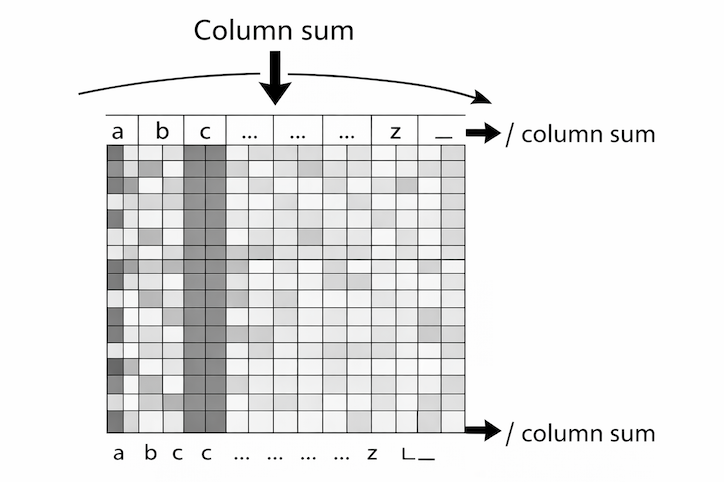

<b>I made this image with chatgpt, it is the best I can show it, but esstentially for each row we divide by it is column sum

In [49]:
P = N.float()
P.shape

torch.Size([27, 27])

<p style="font-size:15px;"> If you don't understand axis in numpy or pytorch you should watch this blog 
  <a href="https://sharpsight.ai/blog/numpy-axes-explained">numpy-axes-explained</a> <br> 

<p style="font-size:15px;">In short: axis 0 would sum each row vertically like over the y-axis, and the result would rows collapse row from 27 into size dimension of (1, 27) from (27, 27) because all the rows would be collapsed , with <code>keepdim=True</code> or vanish <br> <br> 
However, axis=1, would collapse from (27, 27) --> (27, 1), all over x-axis, i.e all columns would sum for each row, so each row had 27, columns will have only one </p>

In [71]:
p_sum = P.sum(1) # we sum over columns, i.e horizontally
p_sum.shape

torch.Size([27])

In [72]:
p_sum = P.sum(1, keepdim=True) # keep dim make it one by 27, instead of just 27
p_sum.shape

torch.Size([27, 1])

In [73]:
psum = P.sum(1)
psum.shape

torch.Size([27])

This has is just 27, not (1x27)

In [76]:
pp = P/psum
# 27 x 27
# 27 x 1
pp.sum(1) # we sum over all columns to get a one

tensor([7.0225, 4.4142, 0.2009, 0.3717, 0.4146, 2.2968, 0.1063, 0.2065, 0.4567,
        2.3526, 0.2220, 0.3551, 1.0512, 0.4841, 1.3317, 1.1396, 0.1160, 0.0719,
        1.1012, 0.8395, 0.5237, 0.5898, 0.1441, 0.0669, 0.1164, 0.8289, 0.1753])

We should have one for all rows, since each row probability should sum to one

In [75]:
pp = P/p_sum
pp.sum(1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

<b>
Why broadcasting failed. 

What are the rules of broadcasting, from pytroch <a href="https://docs.pytorch.org/docs/stable/notes/broadcasting.html"> documentation</a>: 

Two tensors are “broadcastable” if the following rules hold:

- Each tensor has at least one dimension.

- When iterating over the dimension sizes, starting at the trailing dimension, the dimension sizes must either be equal, one of them is 1, or one of them does not exist.



--------------------------------------------------------------------------


<b>
First case 
we had 
(27 x 27)  divided by tensor([27]) 

27 x 27 <br> 
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;x 27 <br> <space> 
    
The rules is align them starting from the end. 
Then <b>Pytorch</b> broadcasted the first dimension of second matrix to be 27 x 27, so it scaled the rows, to match the first matrix. 

So the tensor (27), became 27 x 27, what does that mean, it treated 27 as columns and repeated them 27 times. 
 
but that is false, each row should be divided by the row total, i.e by the same number, so that their sum = 1.
    
But what happened each column were divided by different column sums, like first entry in the first row, were divided by first column that is true, second entry in the first row, were divided by second row 's column sum. 
    

If confused, give it to ChatGPT, or repeat it different times, it will click. <br> <br> 
    
   
The correct case with <code>keepdim=True</code> we ended up with tensor(27x1)<br>
27 x 27 <br> 
27 x 1 <br> <br> 

When broadcasting it would broadcast the columns, <br>
[300]<br>
[200]<br>
[100]<br>

    
--> Broadcast<br>
[300, 300, ...]<br>
[200, 200, ...]<br>
[100, 100, ...]<br>

Broadcast each row up to same number to 27 times, when division happens, each row in original tensor (27 x 27), would be divided by the same number the column sum for that row. 
    


    
    

In [83]:
# P = P/P.sum(1, keepdim=True), this creates a new place in memery
P /= P.sum(1, keepdim=True) # this is does it inplace, so it is more space efficent

In [84]:
P.sum(1) # each row should produce one, the total probability

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [85]:
# Now we can index directly from P
g = torch.Generator().manual_seed(2147483647)
for i in range(20): 
    out = []
    ix = 0 
    while True: 
        ix = torch.multinomial(P[ix], num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break

    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


## Create a loss function

<b>To create a loss function, we have to define a function, that when the model is performing good, it outputs a single number that is close to zero, as the model performs better the number should be closer to 0, and zero means the model performs the best it can based on what we define as our loss. 
    
 

In [92]:
for w in names[:3]: 
    chs = ['.'] + list(w) + ['.'] 
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        prob = P[index1, index2] # probability
        print(x1, x2, f'{prob.item():.4f}')

. e 0.0478
e m 0.0377
m m 0.0253
m a 0.3899
a . 0.1960
. o 0.0123
o l 0.0780
l i 0.1777
i v 0.0152
v i 0.3541
i a 0.1381
a . 0.1960
. a 0.1377
a v 0.0246
v a 0.2495
a . 0.1960


<b>We can visualize the probability for our dataset, for each two characters, so .e have probability of 4%. 

<b>To have a baseline performance, and uniform i.e each character have equally like chance would be $\dfrac{1}{27} = 0.37, \text{about } 4\%$.<br>
    
<b>So, for our above letters, we want to have better probabilities show up more, that is more representative of our data, so when a 'a f' is sampled and that have like 1% we don't want that to happen more often, because that does not resemble our desired approach neither it is representative of the data, because the chance of it occurrence is low.  <span style="font-weight:700; color: rgb(200, 0, 0);"> This key idea, we want higher probabilities to appear more</span> The best case scenario would be all 100% appearance for each predicted/sampled of the next letter. <br>
<br>

<b>Based on Maximum Likelihood function (MLE), we multiply probabilities to measure our statistical model, so we should multiply these probabilities and they product should be a high number, that indicate a better performance. 

In [124]:
import math
props = []
for w in names[:3]: 
    chs = ['.'] + list(w) + ['.'] 
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        prob = P[index1, index2] 
        props.append(prob)
        print(x1, x2, f'{prob.item():.4f}')
    
print()
print(f'final propability: {math.prod(props):.2}')

. e 0.0478
e m 0.0377
m m 0.0253
m a 0.3899
a . 0.1960
. o 0.0123
o l 0.0780
l i 0.1777
i v 0.0152
v i 0.3541
i a 0.1381
a . 0.1960
. a 0.1377
a v 0.0246
v a 0.2495
a . 0.1960

final propability: 1.4e-17


<b>And since multiplying probabilities less than one, would lead to a very small number, we take the log. 

<b>log(1) = 0, and as you remember the log as the number get smaller the number is more negative. 

In [101]:
torch.log(torch.tensor(1)), torch.log(torch.tensor(0.8)), torch.log(torch.tensor(0.5)), torch.log(torch.tensor(0.1))

(tensor(0.), tensor(-0.2231), tensor(-0.6931), tensor(-2.3026))

<b> The more bad the probabilities the more negative is the number

In [107]:
for w in names[:1]: 
    chs = ['.'] + list(w) + ['.'] 
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        prob = P[index1, index2] 
        log_prop = torch.log(prob)
        print(x1, x2, f'{prob.item():.4f}, {log_prop:.2f}')



. e 0.0478, -3.04
e m 0.0377, -3.28
m m 0.0253, -3.68
m a 0.3899, -0.94
a . 0.1960, -1.63


<b> And as we recall we $a \cdot b \cdot c = log(a) + log(b) + log(c)$

In [123]:
log_likelihood = 0.0
for w in names[:2]: 
    chs = ['.'] + list(w) + ['.'] 
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        prob = P[index1, index2] 
        log_prop = torch.log(prob)
        log_likelihood += log_prop
        props.append(prob)
        print(x1, x2, f'{prob.item():.4f}, {log_prop:.2f}')
print()
print(f"{log_likelihood=}")

. e 0.0478, -3.04
e m 0.0377, -3.28
m m 0.0253, -3.68
m a 0.3899, -0.94
a . 0.1960, -1.63
. o 0.0123, -4.40
o l 0.0780, -2.55
l i 0.1777, -1.73
i v 0.0152, -4.19
v i 0.3541, -1.04
i a 0.1381, -1.98
a . 0.1960, -1.63

log_likelihood=tensor(-30.0802)


<b> We said that the loss function when better should be closer to zero when performing better, now lower than zero, while it seems better because that means lower value, it is not bounded by anything, so we take -log, that is better. 

In [122]:
log_likelihood = 0.0
for w in names[:1]: 
    chs = ['.'] + list(w) + ['.'] 
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        prob = P[index1, index2] 
        log_prop = torch.log(prob)
        log_likelihood += log_prop
        print(x1, x2, f'{prob.item():.4f}, {log_prop:.2f}')
n_ll = -log_likelihood
print()
print(f"{log_likelihood=}")
print(f"{n_ll=}")

. e 0.0478, -3.04
e m 0.0377, -3.28
m m 0.0253, -3.68
m a 0.3899, -0.94
a . 0.1960, -1.63

log_likelihood=tensor(-12.5690)
n_ll=tensor(12.5690)


<b> This way very bad probabilities would be negative numbers, summed together, then taking the negative, would be  very high large positive number, which means the model is performing bad. <br> <br>
    
<b>One more thing we add is normalization. 


In [128]:
log_likelihood = 0.0
n = 0
for w in names[:1]: 
    chs = ['.'] + list(w) + ['.'] 
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        prob = P[index1, index2] 
        log_prop = torch.log(prob)
        log_likelihood += log_prop
        n += 1
        print(x1, x2, f'{prob.item():.4f}, {log_prop:.2f}')
n_ll = -log_likelihood
print()
print(f"{log_likelihood=}")
print(f"{n_ll=}")
print(f"{n_ll/n:.2f}")

. e 0.0478, -3.04
e m 0.0377, -3.28
m m 0.0253, -3.68
m a 0.3899, -0.94
a . 0.1960, -1.63

log_likelihood=tensor(-12.5690)
n_ll=tensor(12.5690)
2.51


<span style="font-weight:700; color: rgb(255, 148, 148);">
     So we have this single number that we want to minimize. 
    </span>
<p><b>
GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling). <br>
  - equivalent to maximizing the log likelihood (because log is monotonic) think of it as a scaling down<br>
  - equivalent to minimizing the negative log likelihood<br>
  - equivalent to minimizing the average negative log likelihood this usually done in practice<br>
    
Parameters:this is just the P matrix each probability between two letters is called parameter, we will tune this using a neural network, to find the optimal set of parameters that will make the loss function as low as possible. <br><br>
</p>

<h3 id="model-evaluation">Evaluate Bigram Model</h2>

In [152]:
# To see the loss for a name
log_likelihood = 0.0
n = 0
for w in names: 
    chs = ['.'] + list(w) + ['.'] 
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        prob = P[index1, index2] 
        log_prop = torch.log(prob)
        log_likelihood += log_prop
        n += 1
n_ll = -log_likelihood
print()

print(f"The traing loss for our entire dataset is {n_ll/n:.2f}")


The traing loss for our entire dataset is 2.45


In [170]:
# To see the loss for a name
log_likelihood = 0.0
n = 0
name="omar"
for w in [name]: 
    chs = ['.'] + list(w) + ['.'] 
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        prob = P[index1, index2] 
        log_prop = torch.log(prob)
        log_likelihood += log_prop
        n += 1
        print(x1, x2, f'{prob.item():.4f}, {log_prop:.2f}')
n_ll = -log_likelihood
print()

print(f"The traing loss for a {name} is {n_ll/n:.2f}")

. o 0.0123, -4.40
o m 0.0329, -3.41
m a 0.3899, -0.94
a r 0.0963, -2.34
r . 0.1084, -2.22

The traing loss for a omar is 2.66


Which mean it is not most likely

In [172]:
# To see the loss for a name
log_likelihood = 0.0
n = 0
name="jqohn"
for w in [name]: 
    chs = ['.'] + list(w) + ['.'] 
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        prob = P[index1, index2] 
        log_prop = torch.log(prob)
        log_likelihood += log_prop
        n += 1
        print(x1, x2, f'{prob.item():.4f}, {log_prop:.2f}')
n_ll = -log_likelihood
print()

print(f"The traing loss for a {name} is {n_ll/n:.2f}")

. j 0.0756, -2.58
j q 0.0000, -inf
q o 0.0074, -4.91
o h 0.0216, -3.84
h n 0.0181, -4.01
n . 0.3690, -1.00

The traing loss for a jqohn is inf


<b> The <code>jq</code> have 0 probability which gives negative infinity with log

In [173]:
P = (N+1).float()
P /= P.sum(1, keepdim=True)

<b> This is called <span style="font-weight:700; color: rgb(255, 0, 0);">Model Smoothing </span>we add a number so we avoid this negative infinity. The bigger the number the more flat is the distribution because that would mean 
the differences between individual letters would have less of an effect, like adding 1000, the suddenly the 1200 vs 1100 is not obvious, the difference is only 10%. <br> Compare it before adding 1000. --> 100 vs 200, which is like the double so it would get a double the probability.<br> <br> The distribution would be more smoother and more closer to a uniform with a bigger number, and with a small number it would be more narrow and have higher peak. 


In [178]:
log_likelihood = 0.0
n = 0
name="jqohn"
for w in [name]: 
    chs = ['.'] + list(w) + ['.'] 
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        prob = P[index1, index2] 
        log_prop = torch.log(prob)
        log_likelihood += log_prop
        n += 1
        print(x1, x2, f'{prob.item():.4f}, {log_prop:.2f}')
n_ll = -log_likelihood
print()

print(f"The traing loss for a {name} is {n_ll/n:.2f}")

. j 0.0756, -2.58
j q 0.0003, -7.98
q o 0.0100, -4.60
o h 0.0216, -3.83
h n 0.0182, -4.01
n . 0.3685, -1.00

The traing loss for a jqohn is 4.00


## Training a neural network

Creating a inputs (xs) and targets and (ys) that the model should output. 

So the idea for every letter we input we want a letter output. 

For me this seems to be so bad of an approach, because a name is something can have different variations. 

So while the generally it is bad, on a specific task like this, to output a name that resembles a given dataset 
of names that seems to be natural. 

In [250]:
xs, ys = [], [] 

for w in names[:1]: 
    chs = ['.'] + list(w) + ['.'] 
    for x1, x2 in zip(chs, chs[1:]): 
        index1 = stoi[x1]
        index2 = stoi[x2]
        xs.append(index1)
        ys.append(index2)
        
xs = torch.tensor(xs)
ys = torch.tensor(ys)

xs, xs.dtype

(tensor([ 0,  5, 13, 13,  1]), torch.int64)

In [251]:
import torch.nn.functional as F
xs_onehot = F.one_hot(xs, num_classes=27).float()
W = torch.randn(27,27) #normal distribtution around zero, most values between -1 and 1.

In [252]:
xs_onehot.shape

torch.Size([5, 27])

In [253]:
logits = xs_onehot @ W #log_counts

In [254]:
logits.shape

torch.Size([5, 27])

In [257]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 3.7 MB/s  0:00:02m 3.7 MB/s eta 0:00:01
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [seaborn]━━━━━━━━━━ 2/3 [seaborn]


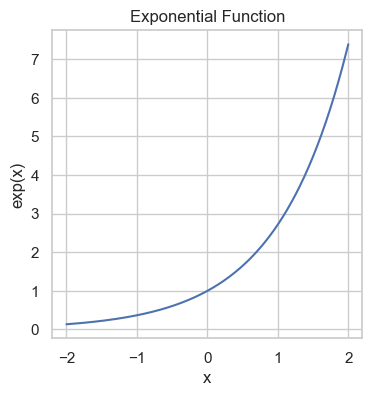

In [261]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))

x = np.linspace(-2, 2, 200)
y = np.exp(x)


sns.set_theme(style="whitegrid")


sns.lineplot(x=x, y=y)

# Labels
plt.xlabel("x")
plt.ylabel("exp(x)")
plt.title("Exponential Function")

plt.show()


Essentially everything will that is less than zero, were negative, and above zero were positive in the first place

In [263]:
counts = logits.exp() # Equaivalent to n matrix
counts

tensor([[ 0.9434,  0.2612,  1.1003,  0.0672,  0.7813,  1.1988,  3.9172,  0.7464,
          1.0632,  1.7549,  1.2613,  2.7472,  2.0440,  1.6826,  1.1658,  1.0764,
          0.2563,  1.2221,  2.5675,  4.2042,  2.1722,  2.0533,  0.7562,  1.3827,
          1.2550,  0.4893,  0.7227],
        [ 1.7360,  0.9138,  0.3089,  2.4496,  0.9784,  0.4614,  1.6493,  0.3818,
          0.4536,  0.2741,  2.2631,  0.2721,  6.3547,  0.5083,  2.4928,  0.7206,
          2.1184,  0.3473,  1.2466,  1.8195,  1.1473,  2.2975,  0.6450,  5.5456,
          5.4684,  0.3916,  0.3149],
        [ 0.3111,  0.2895,  0.6753,  0.7579,  4.3762,  0.8968,  2.5322,  3.6968,
          1.2206,  3.8246, 26.4093,  7.6636,  0.7129,  0.1945,  1.7034,  0.7023,
          0.1109,  0.7926,  1.9971,  5.4945,  2.7541,  1.3522,  0.2098,  0.1023,
          0.5399,  4.2476,  1.0927],
        [ 0.3111,  0.2895,  0.6753,  0.7579,  4.3762,  0.8968,  2.5322,  3.6968,
          1.2206,  3.8246, 26.4093,  7.6636,  0.7129,  0.1945,  1.7034,  0.7023

In [279]:
probs = counts / counts.sum(1, keepdim=True) # softmax
probs

tensor([[0.0243, 0.0067, 0.0283, 0.0017, 0.0201, 0.0308, 0.1007, 0.0192, 0.0273,
         0.0451, 0.0324, 0.0706, 0.0526, 0.0433, 0.0300, 0.0277, 0.0066, 0.0314,
         0.0660, 0.1081, 0.0558, 0.0528, 0.0194, 0.0356, 0.0323, 0.0126, 0.0186],
        [0.0399, 0.0210, 0.0071, 0.0562, 0.0225, 0.0106, 0.0379, 0.0088, 0.0104,
         0.0063, 0.0520, 0.0062, 0.1459, 0.0117, 0.0572, 0.0165, 0.0486, 0.0080,
         0.0286, 0.0418, 0.0263, 0.0527, 0.0148, 0.1273, 0.1255, 0.0090, 0.0072],
        [0.0042, 0.0039, 0.0090, 0.0102, 0.0586, 0.0120, 0.0339, 0.0495, 0.0163,
         0.0512, 0.3537, 0.1026, 0.0095, 0.0026, 0.0228, 0.0094, 0.0015, 0.0106,
         0.0267, 0.0736, 0.0369, 0.0181, 0.0028, 0.0014, 0.0072, 0.0569, 0.0146],
        [0.0042, 0.0039, 0.0090, 0.0102, 0.0586, 0.0120, 0.0339, 0.0495, 0.0163,
         0.0512, 0.3537, 0.1026, 0.0095, 0.0026, 0.0228, 0.0094, 0.0015, 0.0106,
         0.0267, 0.0736, 0.0369, 0.0181, 0.0028, 0.0014, 0.0072, 0.0569, 0.0146],
        [0.0177, 0.0422,

In [280]:
probs[0].sum() # every row sums up to one, like the P matrix. 
# then we backpropgate for this matrix to tune the probabilities to match our data, using our loss function. 

tensor(1.0000)

```md
One coding is an lookup table, what made click for me? 

input1 = [0, 1, 0, 0, 0]  (1×5) - one-hot, position 2 is "on"
input2 = [0, 0, 0, 0, 1]  (1×5) - one-hot, position 5 is "on"

W = 5×3 matrix with 3 neurons (output dimensions)


      neuron1  neuron2  neuron3
row1:   0.3     0.5      0.4
row2:   0.5     0.6      0.2    ← input1 selects THIS
row3:   0.2     0.7      0.6
row4:   0.1     0.3      0.9
row5:   0.5     0.1      0.1    ← input2 selects THIS

Explanation:
From matrix multiplication the ones select the corresponding rows from W. That is why we need 27x27 W matrix. So each one character will select have output dimension of 1x27, 27 columns (neurons) that will be logits. And the highest probability one will be the chosen one. 

Why called Logits? 
Becuase of our loss negative likelihood function, will turn these random initialized weights, into logits, they will approach log scale values, because that is what we are optimizing for. 


Why need exponential? 
Because each one hot encoded after multiplication will end up with (1x27) we want to turn this into probabilities, we use e^x / sum(e^x) for each row. And next character should be the highest probability. 

e^x. 
Range: (0, inf) 
Domain: (-inf, inf)

as x --> ∞, y approaches inf. 
and as x --> -inf, y approaches 0. 
```

### Forward Pas

In [311]:
g = torch.Generator().manual_seed(2147483647) 
W = torch.randn(27, 27, generator=g)

In [312]:
xs_onehot = F.one_hot(xs, num_classes=27).float()
logits = xs_onehot @ W
counts = logits.exp()
probs = counts/ counts.sum(1, keepdim=True)

In [313]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y] # we want this probability as high as possible, because the true target
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.012286250479519367
log likelihood: -4.3992743492126465
negative log likelihood: 4.3992743492126465
--------
bigram example 2: em (indexes 5,13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label (actual next character): 13
probability assigned by the net to the the correct character:

The current loss using our neural network, forward pass for name ".emma" is bad. 

I was confused why he were indexing probability using probs[i], and I forget that the probs is created using 
the one-hot-encoding, so the first character selected from the matrix it is first row, and thirteenth character, did the same, so it is already in the same order as our training dataset, instead of indexing, we used one-hot encoding, it made it easier, then we index to see the output probabilities after Softmax, and then use n_ll, to see the loss for this prediction. 

### Optimiazation

In [315]:
g = torch.Generator().manual_seed(2147483647) 
W = torch.randn(27, 27, generator=g)

In [316]:
xs_onehot = F.one_hot(xs, num_classes=27).float()
logits = xs_onehot @ W
counts = logits.exp()
probs = counts/ counts.sum(1, keepdim=True)

In [317]:
xs

tensor([ 0,  5, 13, 13,  1])

In [318]:
ys

tensor([ 5, 13, 13,  1,  0])

<p style="font-size:15px;">to calculate the loss we want to calculate the negative likelihood of (0,5), (1, 13), etc since xs as stated above was onehot encoded, and selected the probabilities for us, and each character will pull out the same 27 vector from matrix W, we just need to index the correct one using the ys, and optimize for this.</p>


In [319]:
probs[0,5], probs[1, 13], probs[2, 13], probs[3, 1], probs[4, 0]

(tensor(0.0123),
 tensor(0.0181),
 tensor(0.0267),
 tensor(0.0737),
 tensor(0.0150))

Then take negative log and with mean

In [326]:
idx = torch.arange(5)
idx

tensor([0, 1, 2, 3, 4])

In [327]:
probs[idx, ys] # Another way is using vector indexing

tensor([0.0123, 0.0181, 0.0267, 0.0737, 0.0150])

In [329]:
loss = -probs[idx, ys].log().mean()
loss

tensor(3.7693)

Same loss as above loss that using for loop

#### Optimizing 

In [343]:
g = torch.Generator().manual_seed(2147483647) 
W = torch.randn(27, 27, generator=g, requires_grad=True) 

In [344]:
xs_onehot = F.one_hot(xs, num_classes=27).float()
logits = xs_onehot @ W # look up table
counts = logits.exp() # turning it into counts
probs = counts/ counts.sum(1, keepdim=True) # converting into probabilities

## Above is forward pass -------------------------->>> ⬆️
loss = -probs[torch.arange(5), ys].log().mean() # calculating loss
loss

tensor(3.7693, grad_fn=<NegBackward0>)

#### Backward Pass

In [345]:
W.grad = None # Resetting gradient, pytorch will know this, same as setting to zero
loss.backward()

In [347]:
W.grad.shape

torch.Size([27, 27])

In [348]:
lr = 0.1
W.data -= lr * W.grad

Loss now should be slightly lower

In [349]:
xs_onehot = F.one_hot(xs, num_classes=27).float()
logits = xs_onehot @ W 
counts = logits.exp() 
probs = counts/ counts.sum(1, keepdim=True)

loss = -probs[torch.arange(5), ys].log().mean() # calculating loss
loss

tensor(3.7492, grad_fn=<NegBackward0>)

## Complete Neural Network

In [351]:
names = open('names.txt', 'r').read().splitlines() 

In [352]:
# create the dataset
xs, ys = [], []
for w in names:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  228146


That means we have 228,146 bigrams, i.e 228146 examples to train our NN on it

You run the following cells multiple times

In [371]:
# gradient descent
for k in range(30):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad



2.4807207584381104
2.480719566345215
2.4807183742523193
2.4807162284851074
2.480715036392212
2.4807136058807373
2.4807119369506836
2.480710506439209
2.4807090759277344
2.4807074069976807
2.480705738067627
2.4807045459747314
2.480703115463257
2.4807016849517822
2.4807000160217285
2.480698823928833
2.4806971549987793
2.4806957244873047
2.48069429397583
2.4806933403015137
2.480691909790039
2.4806904792785645
2.480689287185669
2.4806878566741943
2.4806861877441406
2.480684995651245
2.4806838035583496
2.480682134628296
2.4806809425354004
2.4806792736053467


Look at section **4.1 evaluate bigram model**, you will see that the NLL was 2.45, which is very closed to what we achieved 
here, so the NN managed to approximate using gradient descent as a bigram model

And the reason for that is that we had are approximating, Bigram model, is 27x27, only, so the best it can achieve is highest probability based on that. 